# Analytics Lab Submission Notebook

This notebook contains the runnable evidence for the analytics extension of the pipeline.

It is organized as:

1. Environment Setup
2. Define Inputs and Configuration
3. Implement Core Logic
4. Run Example Execution
5. Add Basic Validation Checks
6. Save Outputs


## 1. Environment Setup

Import required libraries, configure notebook display, and set a stable random seed.


In [1]:
import json
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# Reproducibility
random.seed(42)
np.random.seed(42)

# Make sure imports from src/ work whether notebook is run from workspace root or notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")

Project root: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor
Python executable: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\.venv\Scripts\python.exe


## 2. Define Inputs and Configuration

Declare paths, constants, and helper configuration used throughout the notebook.


In [2]:
from src.analytics.numpy_ops import main as run_numpy_demo
from src.analytics.data_loader import (
    run_data_loader_pipeline,
    load_from_mongodb,
    export_raw_csv,
    load_from_csv,
    compute_global_mean_from_chunks,
    compute_per_language_mean_from_chunks,
    optimize_dataframe_dtypes,
)
from src.analytics.explorer import run_explorer_pipeline
from src.analytics.quality_report import run_quality_pipeline
from src.analytics.regex_ops import run_regex_pipeline
from src.pipeline.run_pipeline import run_pipeline

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "apple_brand_eda"
CHARTS_DIR = PROCESSED_DIR / "charts"
RAW_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "csv" / "raw_brand_mentions.csv"
LARGE_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "csv" / "apple_ratings_large.csv"

print(f"Processed dir: {PROCESSED_DIR}")
print(f"Charts dir: {CHARTS_DIR}")
print(f"Raw CSV path: {RAW_CSV_PATH}")
print(f"Large CSV path: {LARGE_CSV_PATH}")

c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.3.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Processed dir: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\processed\apple_brand_eda
Charts dir: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\processed\apple_brand_eda\charts
Raw CSV path: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\raw\csv\raw_brand_mentions.csv
Large CSV path: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\raw\csv\apple_ratings_large.csv


## 3. Implement Core Logic

Define helper functions that run each analytics stage and collect outputs in a structured way.


In [3]:
def run_all_sections() -> dict:
    outputs = {}

    # Full integrated pipeline run
    run_pipeline()
    outputs["pipeline_ran"] = True

    # NumPy foundation demo
    run_numpy_demo()
    outputs["numpy_demo_ran"] = True

    # Data loader pipeline (Mongo -> CSV + chunks + optimization)
    loader_results = run_data_loader_pipeline()
    outputs["loader_results"] = loader_results

    # EDA + charts
    explorer_results = run_explorer_pipeline()
    outputs["explorer_results"] = explorer_results

    # Quality checks + heatmap + selector examples
    quality_results = run_quality_pipeline()
    outputs["quality_results"] = quality_results

    # Regex analysis
    regex_results = run_regex_pipeline()
    outputs["regex_results"] = regex_results

    return outputs


def show_chart_grid(charts_dir: Path) -> None:
    chart_files = sorted(charts_dir.glob("*.png"))
    if not chart_files:
        print(f"No chart images found in: {charts_dir}")
        return

    n = len(chart_files)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for idx, chart_path in enumerate(chart_files):
        r, c = divmod(idx, cols)
        img = plt.imread(chart_path)
        axes[r, c].imshow(img)
        axes[r, c].set_title(chart_path.name)
        axes[r, c].axis("off")

    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

## 4. Run Example Execution

Run all analytics steps and display key outputs produced by the pipeline.


INFO: Pipeline started for brand: Apple
INFO: --- Starting Data Ingestion and Parsing ---
INFO: Fetching data from NewsAPI...
INFO: API data fetched. Parsing JSON files...
INFO: MongoDB write complete. New documents: 9, Updated documents: 9.
INFO:src.storage.mongo:MongoDB write complete. New documents: 9, Updated documents: 9.
INFO: MongoDB write complete. New documents: 9, Updated documents: 10.
INFO:src.storage.mongo:MongoDB write complete. New documents: 9, Updated documents: 10.
INFO: MongoDB write complete. New documents: 8, Updated documents: 11.
INFO:src.storage.mongo:MongoDB write complete. New documents: 8, Updated documents: 11.
INFO: Parsing CSV files...
INFO:src.pipeline.run_pipeline:Parsing CSV files...
INFO: MongoDB write complete. New documents: 0, Updated documents: 5000.
INFO:src.storage.mongo:MongoDB write complete. New documents: 0, Updated documents: 5000.
INFO: MongoDB write complete. New documents: 0, Updated documents: 192.
INFO:src.storage.mongo:MongoDB write co

NumPy array creation methods for the Apple brand monitor project

1. np.array() from daily Apple mention counts
[120 135 128 142 150]
shape: (5,)
dtype: int64
ndim: 1

2. np.arange() for hourly monitoring windows
[ 0  4  8 12 16 20]
shape: (6,)
dtype: int64
ndim: 1

3. np.linspace() for engagement score scale
[0.   0.25 0.5  0.75 1.  ]
shape: (5,)
dtype: float64
ndim: 1

4. np.zeros() for unresolved complaint counts
[[0 0 0]
 [0 0 0]]
shape: (2, 3)
dtype: int64
ndim: 2

5. np.ones() for campaign baseline matrix
[[1. 1.]
 [1. 1.]
 [1. 1.]]
shape: (3, 2)
dtype: float64
ndim: 2

Vectorized arithmetic with no Python loops

Original daily mentions
[120 135 128 142 150]

Original positive sentiment counts
[ 82  90  85  95 102]

Add 15 mentions to every day
[135 150 143 157 165]

Double sentiment counts
[164 180 170 190 204]

Add two arrays element-wise
[202 225 213 237 252]

Divide arrays element-wise
[0.68333333 0.66666667 0.6640625  0.66901408 0.68      ]


INFO: Processed language chunk 1 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 1 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 2 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 2 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 3 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 3 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 4 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 4 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 5 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 5 | languages=['de', 'en', 'es', 'fr']
INFO: Per-language accumulator combination finished | means={'de': 3.0, 'en': 3.0, 'es': 3.0, 'fr': 3.0}
INFO:src.analytics.data_loader:Per-language accumulator combination fi

NumPy array creation methods for the Apple brand monitor project

1. np.array() from daily Apple mention counts
[120 135 128 142 150]
shape: (5,)
dtype: int64
ndim: 1

2. np.arange() for hourly monitoring windows
[ 0  4  8 12 16 20]
shape: (6,)
dtype: int64
ndim: 1

3. np.linspace() for engagement score scale
[0.   0.25 0.5  0.75 1.  ]
shape: (5,)
dtype: float64
ndim: 1

4. np.zeros() for unresolved complaint counts
[[0 0 0]
 [0 0 0]]
shape: (2, 3)
dtype: int64
ndim: 2

5. np.ones() for campaign baseline matrix
[[1. 1.]
 [1. 1.]
 [1. 1.]]
shape: (3, 2)
dtype: float64
ndim: 2

Vectorized arithmetic with no Python loops

Original daily mentions
[120 135 128 142 150]

Original positive sentiment counts
[ 82  90  85  95 102]

Add 15 mentions to every day
[135 150 143 157 165]

Double sentiment counts
[164 180 170 190 204]

Add two arrays element-wise
[202 225 213 237 252]

Divide arrays element-wise
[0.68333333 0.66666667 0.6640625  0.66901408 0.68      ]


INFO:src.analytics.data_loader:Processed language chunk 1 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 2 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 2 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 3 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 3 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 4 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 4 | languages=['de', 'en', 'es', 'fr']
INFO: Processed language chunk 5 | languages=['de', 'en', 'es', 'fr']
INFO:src.analytics.data_loader:Processed language chunk 5 | languages=['de', 'en', 'es', 'fr']
INFO: Per-language accumulator combination finished | means={'de': 3.0, 'en': 3.0, 'es': 3.0, 'fr': 3.0}
INFO:src.analytics.data_loader:Per-language accumulator combination finished | means={'de': 3.0, 'en': 3.0, 'es': 3.0, 'fr': 3.0}
INFO: Anal

Pipeline and analytics execution completed.
Raw CSV export: data\raw\csv\raw_brand_mentions.csv
Chunk CSV path: data\raw\csv\apple_ratings_large.csv
Global mean rating: 3.0
Per-language means: {'de': 3.0, 'en': 3.0, 'es': 3.0, 'fr': 3.0}
EDA report path: data\processed\apple_brand_eda\apple_brand_eda_report.txt
Quality report path: data\processed\apple_brand_eda\apple_quality_report.csv
Regex output path: data\processed\apple_brand_eda\apple_regex_results.csv

Displaying generated charts:


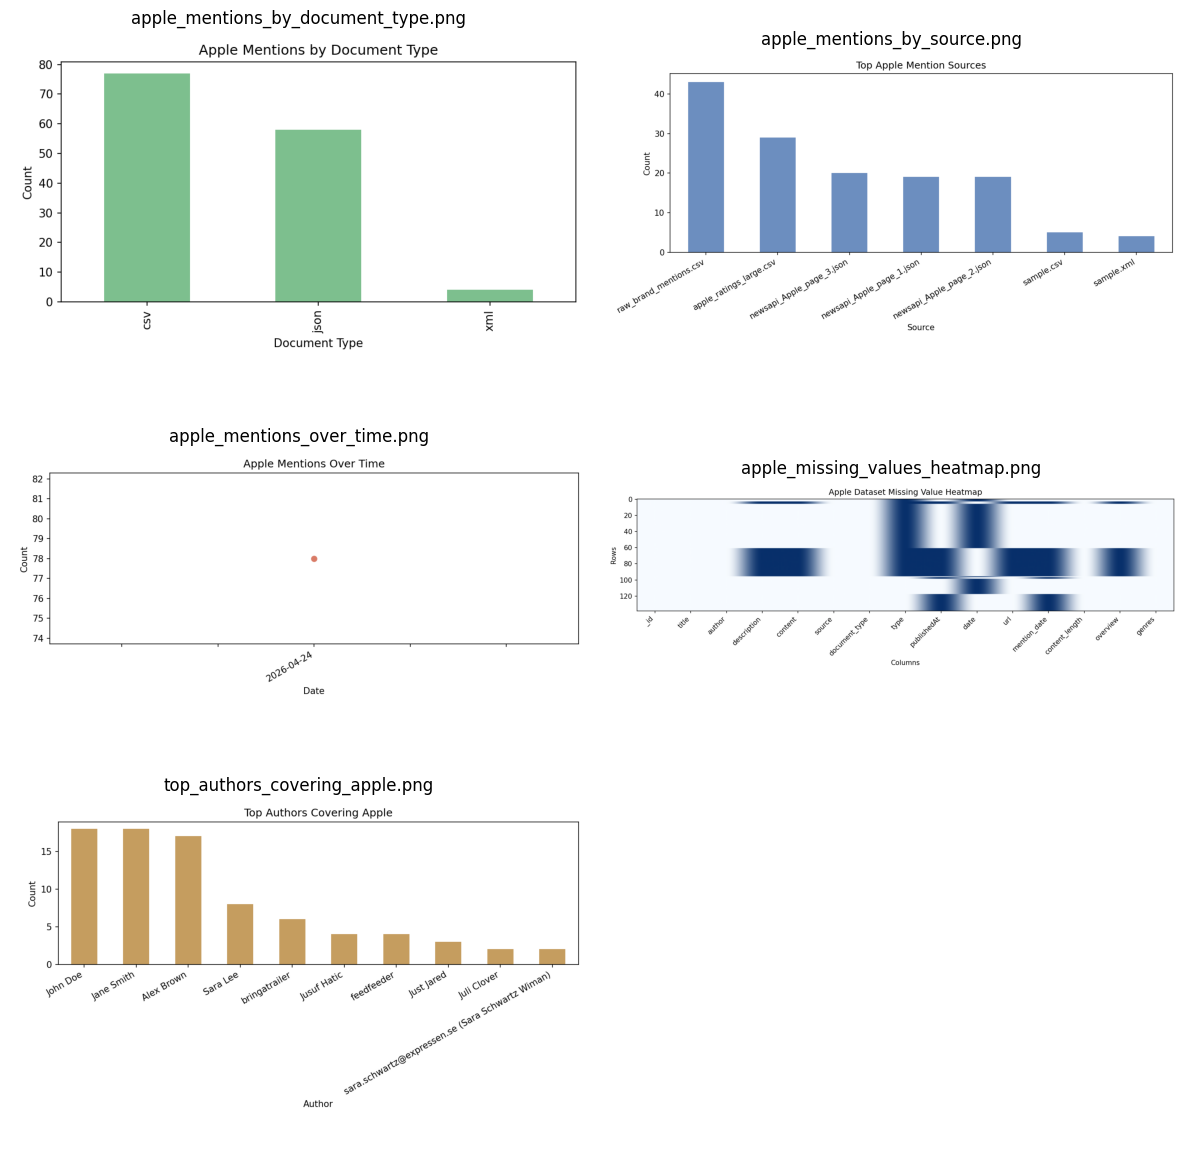

In [4]:
results = run_all_sections()

loader_results = results["loader_results"]
explorer_results = results["explorer_results"]
quality_results = results["quality_results"]
regex_results = results["regex_results"]

print("Pipeline and analytics execution completed.")
print(f"Raw CSV export: {loader_results.get('export_path')}")
print(f"Chunk CSV path: {loader_results.get('chunk_csv_path')}")
print(f"Global mean rating: {loader_results.get('global_mean_rating')}")
print(f"Per-language means: {loader_results.get('per_language_means')}")
print(f"EDA report path: {explorer_results.get('report_path')}")
print(f"Quality report path: {quality_results.get('quality_report_path')}")
print(f"Regex output path: {regex_results.get('output_path')}")

print("\nDisplaying generated charts:")
show_chart_grid(CHARTS_DIR)

## 5. Add Basic Validation Checks

Run lightweight assertions to verify expected outputs and file artifacts exist.


In [5]:
required_files = [
    PROCESSED_DIR / "apple_brand_eda_report.txt",
    PROCESSED_DIR / "apple_quality_report.csv",
    PROCESSED_DIR / "apple_quality_issues.csv",
    PROCESSED_DIR / "apple_regex_results.csv",
    PROCESSED_DIR / "apple_selection_examples.txt",
    CHARTS_DIR / "apple_mentions_by_source.png",
    CHARTS_DIR / "apple_mentions_by_document_type.png",
    CHARTS_DIR / "apple_mentions_over_time.png",
    CHARTS_DIR / "top_authors_covering_apple.png",
    CHARTS_DIR / "apple_missing_values_heatmap.png",
]

for path in required_files:
    assert path.exists(), f"Missing expected output: {path}"

assert loader_results.get("global_mean_rating") is not None
assert isinstance(loader_results.get("per_language_means"), dict)
assert len(loader_results.get("per_language_means")) > 0

print("All basic validation checks passed.")

All basic validation checks passed.


## 6. Save Outputs

Export a compact JSON summary of key metrics and output paths for submission tracking.


In [6]:
summary = {
    "global_mean_rating": loader_results.get("global_mean_rating"),
    "per_language_means": loader_results.get("per_language_means"),
    "memory_before_mb": loader_results.get("memory_before_mb"),
    "memory_after_mb": loader_results.get("memory_after_mb"),
    "eda_report": str(PROCESSED_DIR / "apple_brand_eda_report.txt"),
    "quality_report": str(PROCESSED_DIR / "apple_quality_report.csv"),
    "quality_issues": str(PROCESSED_DIR / "apple_quality_issues.csv"),
    "regex_results": str(PROCESSED_DIR / "apple_regex_results.csv"),
}

summary_path = PROCESSED_DIR / "notebook_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Summary saved.")
print(f"Summary path: {summary_path}")
print(json.dumps(summary, indent=2))

Summary saved.
Summary path: c:\Users\topic\OneDrive\Desktop\PROJECTS\Projekat za unstructured data\social_media_brand_monitor\data\processed\apple_brand_eda\notebook_summary.json
{
  "global_mean_rating": 3.0,
  "per_language_means": {
    "de": 3.0,
    "en": 3.0,
    "es": 3.0,
    "fr": 3.0
  },
  "memory_before_mb": 1.3448028564453125,
  "memory_after_mb": 0.0408477783203125,
  "eda_report": "c:\\Users\\topic\\OneDrive\\Desktop\\PROJECTS\\Projekat za unstructured data\\social_media_brand_monitor\\data\\processed\\apple_brand_eda\\apple_brand_eda_report.txt",
  "quality_report": "c:\\Users\\topic\\OneDrive\\Desktop\\PROJECTS\\Projekat za unstructured data\\social_media_brand_monitor\\data\\processed\\apple_brand_eda\\apple_quality_report.csv",
  "quality_issues": "c:\\Users\\topic\\OneDrive\\Desktop\\PROJECTS\\Projekat za unstructured data\\social_media_brand_monitor\\data\\processed\\apple_brand_eda\\apple_quality_issues.csv",
  "regex_results": "c:\\Users\\topic\\OneDrive\\Deskto